# How Much Does a Better Forecast Help?

This companion revisits Part I's deterministic battery-arbitrage model. It uses past CAISO day-ahead prices as **backcasts**: at each decision time, construct a forecast ensemble from observations that were already available, make one control decision, observe the next price, and repeat.

The question is practical: **how much value does a better forecast create?** We answer it with closed-loop, receding-horizon simulation and the stochastic-programming metrics EVPI and VSS.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 7 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

## Learning goals

- Build forecast scenarios without using future observations.
- Compare an expected-value schedule with a two-stage stochastic schedule.
- Run a closed-loop model-predictive-control (MPC) backtest.
- Interpret the expected value of perfect information (EVPI) and value of the stochastic solution (VSS).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

if "google.colab" in sys.modules:
    !wget -q https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

SOLVER = pyo.SolverFactory("appsi_highs")
assert SOLVER.available(exception_flag=False), "Install HiGHS before running this notebook."

Matplotlib is building the font cache; this may take a moment.


## Backcasting forecast scenarios

The repository carries hourly 2015 CAISO day-ahead prices for one node. At decision hour $t$, the seven scenarios below are the corresponding 24-hour windows from the previous seven days. Every scenario ends at or before $t$; none leaks a future price into the forecast. This simple historical ensemble is a baseline that can later be replaced by a fitted forecasting model.

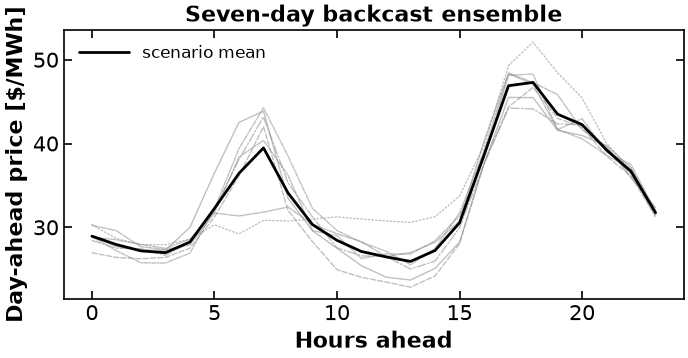

In [2]:
prices = pd.read_csv(Path("https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/Prices_DAM_ALTA2G_7_B1.csv"), names=["price"])["price"].to_numpy(float)
HORIZON, N_SCENARIOS = 24, 7
FIRST_BACKTEST_HOUR, BACKTEST_HOURS = 14 * 24, 48
assert FIRST_BACKTEST_HOUR >= N_SCENARIOS * 24
assert FIRST_BACKTEST_HOUR + BACKTEST_HOURS + HORIZON <= len(prices)

def backcast_scenarios(price_history, decision_hour, horizon=HORIZON, n_scenarios=N_SCENARIOS):
    """Historical day-ahead paths available strictly before decision_hour."""
    starts = [decision_hour - 24 * day for day in range(1, n_scenarios + 1)]
    scenarios = np.vstack([price_history[start : start + horizon] for start in starts])
    assert max(start + horizon for start in starts) <= decision_hour
    return scenarios

scenarios = backcast_scenarios(prices, FIRST_BACKTEST_HOUR)
fig, ax = plt.subplots(figsize=(8, 3.5))
for path in scenarios:
    ax.plot(path, color="0.55", alpha=0.55, linewidth=1)
ax.plot(scenarios.mean(axis=0), color="black", linewidth=2, label="scenario mean")
ax.set(xlabel="Hours ahead", ylabel="Day-ahead price [$/MWh]", title="Seven-day backcast ensemble")
ax.legend(); plt.show()

## Two-stage stochastic battery model

Each scenario has charging power $c_{s,t}$, discharging power $d_{s,t}$, and stored energy $E_{s,t}$. The first-hour charge and discharge decisions are equal across scenarios. This **non-anticipativity** constraint means that the implemented action cannot depend on the price path that later occurs. The terminal-energy constraint prevents artificial value from emptying the battery at the end of the planning horizon.

In [3]:
def build_battery_model(price_scenarios, initial_energy):
    """Two-stage stochastic battery-arbitrage LP; only t=0 is here-and-now."""
    price_scenarios = np.asarray(price_scenarios, dtype=float)
    n_scenarios, horizon = price_scenarios.shape
    m = pyo.ConcreteModel()
    m.S = pyo.RangeSet(0, n_scenarios - 1)
    m.T = pyo.RangeSet(0, horizon - 1)
    m.price = pyo.Param(m.S, m.T, initialize=lambda m, s, t: price_scenarios[s, t])
    m.charge = pyo.Var(m.S, m.T, bounds=(0, 1.0))
    m.discharge = pyo.Var(m.S, m.T, bounds=(0, 1.0))
    m.energy = pyo.Var(m.S, m.T, bounds=(0, 4.0))
    eta = 0.92
    def balance(m, s, t):
        previous = initial_energy if t == 0 else m.energy[s, t - 1]
        return m.energy[s, t] == previous + eta * m.charge[s, t] - m.discharge[s, t] / eta
    m.balance = pyo.Constraint(m.S, m.T, rule=balance)
    m.terminal = pyo.Constraint(m.S, rule=lambda m, s: m.energy[s, horizon - 1] == initial_energy)
    m.same_charge = pyo.Constraint(m.S, rule=lambda m, s: m.charge[s, 0] == m.charge[0, 0])
    m.same_discharge = pyo.Constraint(m.S, rule=lambda m, s: m.discharge[s, 0] == m.discharge[0, 0])
    m.profit = pyo.Objective(expr=sum(m.price[s, t] * (m.discharge[s, t] - m.charge[s, t]) for s in m.S for t in m.T) / n_scenarios, sense=pyo.maximize)
    return m

def solve(model):
    result = SOLVER.solve(model)
    assert pyo.check_optimal_termination(result), result.solver.termination_condition
    return model

def first_action(model):
    return float(pyo.value(model.charge[0, 0])), float(pyo.value(model.discharge[0, 0]))

## EVPI and VSS

At one forecast origin, compare three profit values: **RP**, the recourse-problem value from the stochastic model; **EEV**, the result of fixing the expected-value model's first action and then evaluating it over all scenarios; and **WS**, the average perfect-foresight result. For profit maximization, $\mathrm{VSS}=RP-EEV$ and $\mathrm{EVPI}=WS-RP$. Both are nonnegative up to solver tolerances.

In [4]:
def information_metrics(scenarios, initial_energy=2.0):
    stochastic = solve(build_battery_model(scenarios, initial_energy))
    rp = float(pyo.value(stochastic.profit))
    expected_value = solve(build_battery_model(scenarios.mean(axis=0)[None, :], initial_energy))
    charge, discharge = first_action(expected_value)
    eev_model = build_battery_model(scenarios, initial_energy)
    for s in eev_model.S:
        eev_model.charge[s, 0].fix(charge)
        eev_model.discharge[s, 0].fix(discharge)
    eev = float(pyo.value(solve(eev_model).profit))
    ws = np.mean([float(pyo.value(solve(build_battery_model(scenarios[s:s + 1], initial_energy)).profit)) for s in range(scenarios.shape[0])])
    return {"RP": rp, "EEV": eev, "WS": ws, "VSS": rp - eev, "EVPI": ws - rp}

pd.Series(information_metrics(scenarios), name="profit [$]").to_frame().round(2)

,profit [$]
RP,53.9
EEV,53.9
WS,53.9
VSS,0.0
EVPI,0.0


## Closed-loop MPC backtest

At each hour, construct a new forecast ensemble, solve a 24-hour optimization problem, implement only its first action, observe the actual price, update stored energy, and replan. This is model-predictive control. The comparison below gives both policies the same realized prices; only their forecast-treatment differs.

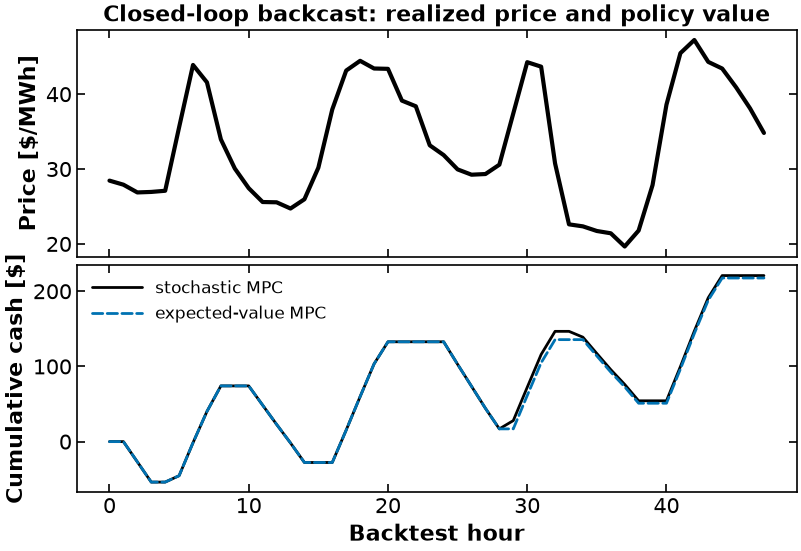

In [5]:
def run_backtest(policy, price_history, first_hour, n_hours, initial_energy=2.0):
    energy, cash, rows = initial_energy, 0.0, []
    for hour in range(first_hour, first_hour + n_hours):
        scenarios = backcast_scenarios(price_history, hour)
        if policy == "stochastic":
            model = solve(build_battery_model(scenarios, energy))
        elif policy == "expected value":
            model = solve(build_battery_model(scenarios.mean(axis=0)[None, :], energy))
        else:
            raise ValueError(policy)
        charge, discharge = first_action(model)
        energy += 0.92 * charge - discharge / 0.92
        cash += price_history[hour] * (discharge - charge)
        rows.append({"hour": hour, "price": price_history[hour], "energy": energy, "cash": cash})
    return pd.DataFrame(rows)

stochastic_run = run_backtest("stochastic", prices, FIRST_BACKTEST_HOUR, BACKTEST_HOURS)
expected_run = run_backtest("expected value", prices, FIRST_BACKTEST_HOUR, BACKTEST_HOURS)
pd.DataFrame({"stochastic MPC": [stochastic_run.cash.iloc[-1], stochastic_run.energy.iloc[-1]], "expected-value MPC": [expected_run.cash.iloc[-1], expected_run.energy.iloc[-1]]}, index=["realized cash [$]", "final energy [MWh]"]).round(2)

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, layout="constrained")
hours = np.arange(BACKTEST_HOURS)
axes[0].plot(hours, stochastic_run.price, color="black")
axes[0].set(ylabel="Price [$/MWh]", title="Closed-loop backcast: realized price and policy value")
axes[1].plot(hours, stochastic_run.cash, label="stochastic MPC", linewidth=2)
axes[1].plot(hours, expected_run.cash, label="expected-value MPC", linestyle="--", linewidth=2)
axes[1].set(xlabel="Backtest hour", ylabel="Cumulative cash [$]")
axes[1].legend(); plt.show()

## Interpret

1. Is VSS materially different from zero at this forecast origin? Why can EVPI be positive when VSS is small?
2. Did the two closed-loop policies earn different realized cash over this short backtest? One backtest is one realization, not proof of average performance.
3. Improve one modeling choice: the scenario construction, terminal value, battery model, or forecasting method. State what information your change uses and whether it is available at the decision time.

A useful next step is a statistical forecasting model. Compare forecast skill, VSS, and realized closed-loop value to measure whether a better forecast helps enough to matter.